# Olds vs currents: the off-the-run switch, across the curve

**The trade.** Buy a seasoned Treasury, sell the on-the-run of the same original-issue
tenor, duration-matched. The on-the-run is rich because it is liquid; when the next
auction displaces it, that richness is released and the spread converges. The study runs
every pair among CT / O / OO / OOO (current, old, double-old, triple-old) on the 2y, 3y,
5y, 7y, 10y, 20y and 30y, 2010 to 2026, marked daily, with the equity curve in basis
points of a DV01-matched position.

**Order of operations, and why it is not the obvious one.** Coverage, then the *raw
object* (yield pickup by rank with no trading rule on it), then ONE hand-reconciled
trade, then the baseline, and only then the grid. The raw object comes first because if
the premium is not there, a grid run first would only report which noise it liked. The
reconciled trade comes next because five hundred wrong numbers look exactly like five
hundred right ones.

**Three things this config deliberately cannot do.**
1. It cannot hold a position by ALIAS. `O10/CT10` is a different pair of bonds either
   side of an auction; measured on the 2024-02-16 refunding the alias series moved
   −1.395bp day-over-day while the pair actually held moved −0.358bp. Differencing the
   alias books 1.04bp nobody earned, on a trade whose whole premium is 0.1–1.8bp.
   Positions are pinned to CUSIPs at entry.
2. It cannot use the engine's native carry. `Query/FixedRateBonds/carry_roll.py` applies
   ONE rate — the last overnight SOFR fixing — to every bond, so both legs of a switch
   finance identically, the financing nets to zero and the trade looks free. It is not.
3. It cannot silently reduce its trial count. Placebos and controls are counted in the
   deflation alongside the configurations that were being hoped for.

> ⚠ **The caveat that matters most.** The raw spread between two ranks is not a pure
> liquidity premium: the older bond also matures ~1–3 months earlier, so the spread
> carries a slice of curve slope. That component is roughly static while a position is
> on (both bonds age together), but it sets the LEVEL, and in some regimes it dominates
> the sign. §2 shows this directly — in 2015–16 the 10y rank-3 yielded *less* than the
> on-the-run, which no liquidity story explains.

In [1]:
import os, sys, pathlib, warnings, json

os.environ.setdefault("ARBS_SUPABASE_ENABLED", "0")
warnings.filterwarnings("ignore")

# Derived, never hardcoded: the FOMC builder pins `ARBS-gcb` and silently imports another
# worktree's code when copied. `_make_v3_notebooks.py` derives it for exactly this reason.
REPO = str(pathlib.Path.cwd().parents[2]) if pathlib.Path.cwd().name == "ust_switch" else os.getcwd()
sys.path.insert(0, REPO)

import numpy as np
import pandas as pd

from RVUtils.USTSwitch import analytics as A
from RVUtils.USTSwitch import figures as F
from RVUtils.USTSwitch import grid as G
from RVUtils.USTSwitch.costs import CostModel, cost_table_summary
from RVUtils.USTSwitch.data import coverage_report, load_prepared, select_financing
from RVUtils.USTSwitch.engine import SwitchConfig, run_switch

plt = F.style()
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

panel, amap = load_prepared()
print(f"panel {panel.shape}  {panel['date'].min().date()} .. {panel['date'].max().date()}")

panel (105298, 23)  2010-01-04 .. 2026-08-17


## 1. The config

One frozen dataclass. Every field is a knob the later sections sweep one at a time.

In [2]:
CONFIG = SwitchConfig(
    tenor=10,
    rank_young=0,       # CT  -- the on-the-run, the leg you short in the classic switch
    rank_old=1,         # O   -- the seasoned leg you buy
    direction=1,        # +1 = long old / short current
    entry_offset=1,     # business days after the auction roll
    exit_rule="next_roll",
    exit_offset=1,
    financing_mode="modelled",
    cost_multiplier=1.0,
)
print(CONFIG.name)

10Y_CTvO_LONGOLD_e1_nr+1_finmodelled_c1


### 1.1 Recipes

In [3]:
RECIPES = {
    "classic 10y O-vs-CT": dict(tenor=10, rank_young=0, rank_old=1, direction=1),
    "deep 30y OOO-vs-CT": dict(tenor=30, rank_young=0, rank_old=3, direction=1),
    "20y O-vs-CT (richest specialness)": dict(tenor=20, rank_young=0, rank_old=1, direction=1),
    "fade (short the old)": dict(tenor=10, rank_young=0, rank_old=1, direction=-1),
    "measured financing only": dict(financing_mode="actual"),
    "no financing (control)": dict(financing_mode="none"),
}

## 2. What the study can see, and what the trade is made of

Coverage first. `financing_actual` is the fraction of rows with **measured** per-issue
repo (the JPM package, 2016-08-10 to 2025-08-26); outside that window specialness is
modelled by (tenor, rank, age) and every headline is reported in all three financing
modes so the model's contribution is visible rather than assumed.

In [4]:
cov = coverage_report(panel)
display(cov)
print(f"rows with measured financing: {panel['has_actual_financing'].mean():.1%}")

,tenor,first,last,days,rows,cusips,ytm_nan,financing_actual,mean_special_bp
0,2,2010-01-04,2026-08-17,4148,16581,193,0.0,0.5326,5.1052
1,3,2010-01-04,2026-08-17,4148,16581,202,0.0,0.5336,3.5085
2,5,2010-01-04,2026-08-17,4148,16581,195,0.0,0.5336,4.7756
3,7,2010-01-04,2026-08-17,4148,16581,203,0.0,0.5339,2.6298
4,10,2010-01-04,2026-08-17,4148,16586,70,0.0,0.5336,6.4715
5,20,2020-06-02,2026-08-17,1545,5800,25,0.0,0.8062,6.0666
6,30,2010-01-04,2026-08-17,4148,16588,70,0.0,0.5307,4.2238


rows with measured financing: 54.8%


### 2.1 The raw object — yield pickup by rank, before any trading rule

This is the whole trade in one table. If the pickup is not monotone in rank, the
liquidity premium is not the dominant term and no configuration will rescue it.

rank     n  mean_pickup_bp  median_pickup_bp  std_bp
tenor                                                        
2     0     1  4143           0.149            -0.001   2.608
      1     2  4143          -0.163            -0.519   4.677
      2     3  4143          -0.585            -1.349   6.814
3     0     1  4143          -0.806            -0.780   1.785
      1     2  4143          -1.768            -1.440   3.377
      2     3  4143          -2.719            -2.306   4.890
5     0     1  4143          -0.577            -0.460   1.675
      1     2  4143          -1.465            -0.973   2.831
      2     3  4143          -2.456            -1.604   4.011
7     0     1  4143          -0.710            -0.540   1.068
      1     2  4143          -1.485            -1.146   2.008
      2     3  4143          -2.290            -1.812   2.928
10    0     1  4144          -0.983            -0.530   1.821
      1     2  4144          -2.695            -1.614   3.600
      2     3  4144          -4.650            -3.009   5.357
20    0     1  1478           0.590             0.550   1.342
      1     2  1418           0.949             0.677   2.339
      2     3  1358           1.137             0.777   3.684
30    0     1  4146           0.248             0.263   1.070
      1     2  4147           0.416             0.430   1.978
      2     3  4147           0.408             0.551   2.396

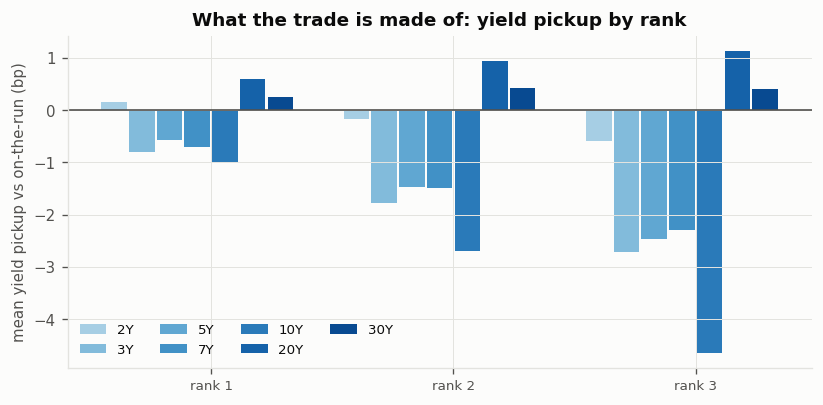

In [5]:
ts = {t: A.spread_term_structure(panel, t) for t in G.TENORS}
ts = {t: d for t, d in ts.items() if d is not None and not d.empty}
display(pd.concat(ts, names=["tenor"]).round(3))
F.plot_spread_term_structure(ts)
plt.show()

### 2.2 The cost line, from NY Fed Staff Report 1170 Table 3

Effective bid-ask by off-the-run rank, converted from price bp to yield bp by modified
duration. Printed **before** any P&L, because every prior lab in this repo died on the
cost line and the cost was the last thing shown.

In [6]:
ct = cost_table_summary()
display(ct.pivot_table(index="tenor", columns="pair", values="rt_cost_bp").round(3))

pair,O/CT,OO/CT,OO/O,OOO/CT,OOO/O,OOO/OO
tenor,,,,,,
2,0.990,1.521,1.816,1.621,1.916,2.447
3,1.243,1.536,1.936,1.811,2.211,2.504
5,0.773,0.956,1.204,1.127,1.376,1.558
7,0.951,1.218,1.490,1.331,1.603,1.870
10,0.734,0.940,1.151,1.028,1.238,1.444
20,0.975,1.664,1.686,2.036,2.057,2.746
30,0.579,0.989,1.002,1.210,1.222,1.632


### 2.3 Financing — measured specialness by tenor and rank

Reproduced from the JPM package and tied out against their published `3m Repo Special`
at corr 0.9997 (mean abs error 0.037bp). The 20y is by far the most special.

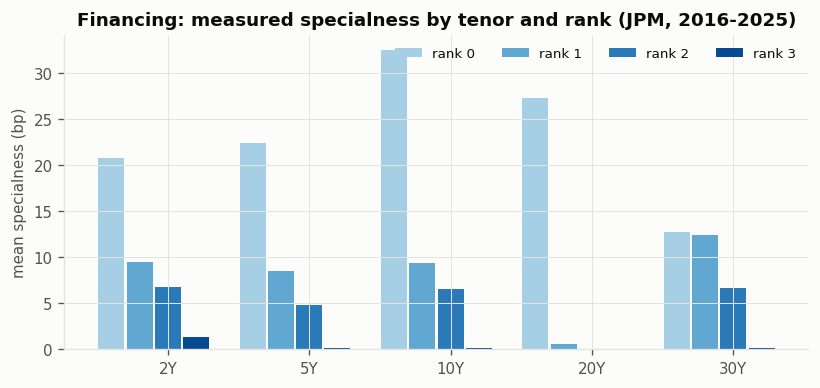

rank,0,1,2,3
tenor,,,,
2,20.769,9.447,6.776,1.356
3,11.756,7.845,6.144,0.538
5,22.362,8.539,4.759,0.166
7,7.993,6.153,5.347,0.214
10,32.460,9.373,6.496,0.176
20,27.263,0.607,0.034,0.013
30,12.702,12.363,6.673,0.099


In [7]:
F.plot_specialness(panel)
plt.show()
display(panel[panel["has_actual_financing"]]
        .groupby(["tenor", "rank"])["special_actual_bp"].mean().unstack().round(3))

## 3. Does the machine give the right answer to a question we already know?

The known-answer gate. One trade is recomputed from the raw panel by arithmetic that
does not touch engine code, and the reconciliation is then broken on purpose — once by
flipping the direction, once by removing the specialness — to prove it is sensitive to
both. A reconciliation that passes either way is checking nothing.

In [8]:
# ! python reconcile_one_trade.py
import subprocess
print(subprocess.run([sys.executable, str(pathlib.Path(REPO) / "notebooks/backtests/ust_switch/reconcile_one_trade.py")],
                     capture_output=True, text=True).stdout)

=== reconciling one trade ===
config : 10Y_CTvO_LONGOLD_e1_nr+1_finactual_c1
cycle  : roll 2022-08-16  entry 2022-08-17  exit 2022-11-17
legs   : LONG(old) 91282CEP2   SHORT(current) 91282CFF3
obs    : 64 marks over 92 calendar days

--- engine vs hand, as configured ---
field                   engine       by hand          diff
price_bp            0.74658289    0.74658289      0.00e+00
carry_bp           -0.23715388   -0.23715388      0.00e+00
special_bp         -0.32438343   -0.32438343      0.00e+00
cost_bp             0.68383563    0.68383563      0.00e+00
net_bp             -0.17440662   -0.17440662      1.11e-16
  => MATCH  (expected MATCH)  OK

--- engine vs hand with direction FLIPPED (must MISMATCH) ---
field                   engine       by hand          diff
price_bp            0.74658289   -0.74658289      1.49e+00
carry_bp           -0.23715388    0.23715388     -4.74e-01
special_bp         -0.32438343    0.32438343     -6.49e-01
cost_bp             0.68383563    0.683835

## 4. How this config performed

funnel: {'cycles': 65, 'no_entry_date': 0, 'leg_missing_at_entry': 0, 'no_exit_date': 0, 'short_history': 0, 'z_filtered': 0, 'traded': 65}


,component,total_bp,per_trade_bp,n_trades
0,price (spread move),72.5748,1.1165,65
1,carry (total),-30.0346,-0.4621,65
2,of which specialness,-33.5110,-0.5156,65
3,cost (execution),-43.8976,-0.6753,65
4,NET,-1.3575,-0.0209,65


,value
name,10Y_CTvO_LONGOLD_e1_nr+1_finmodelled_c1
tenor,10
pair,CTvO
direction,1
entry_offset,1
exit_rule,next_roll
exit_offset,1
hold_days,21
z_window,None
z_entry,None


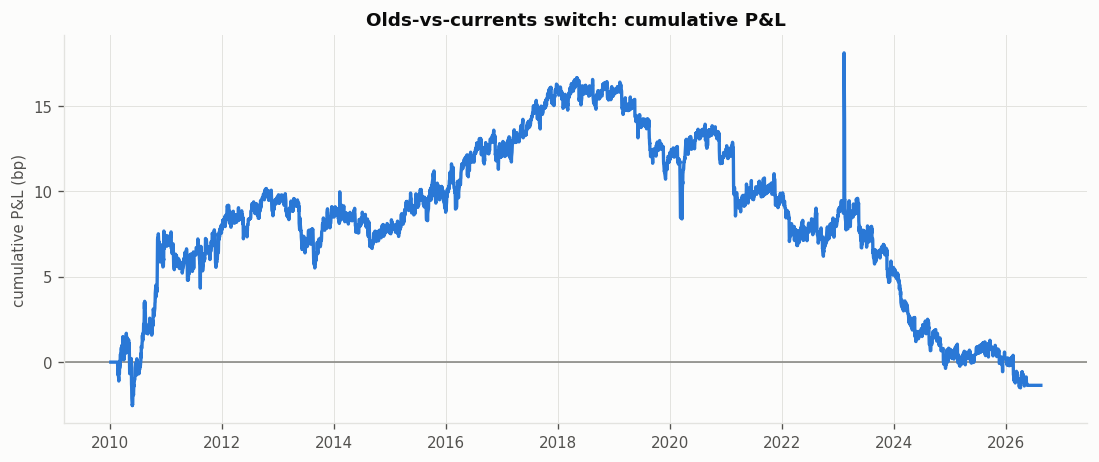

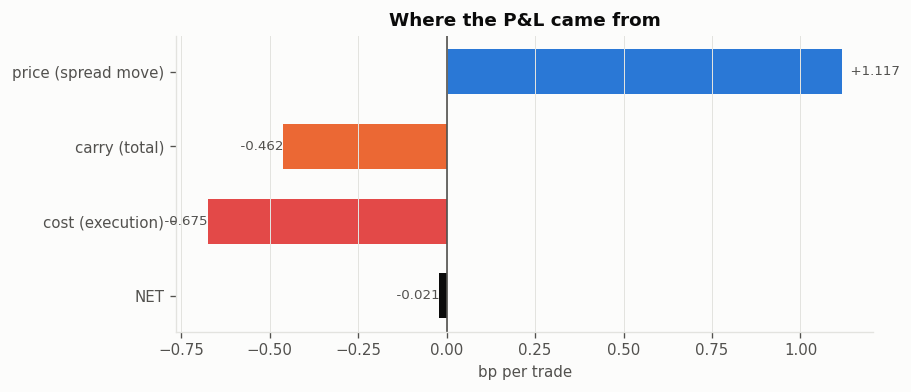

In [9]:
p_fin = select_financing(panel, CONFIG.financing_mode)
res = run_switch(p_fin, amap, CONFIG, cost_model=CostModel(multiplier=CONFIG.cost_multiplier))
print("funnel:", res.funnel)
display(A.pnl_decomposition(res).round(4))
summ = A.summarize_switch(res)
display(pd.Series(summ).to_frame("value"))

F.plot_equity({CONFIG.name: res.equity_bp})
plt.show()
F.plot_pnl_decomposition(A.pnl_decomposition(res))
plt.show()

## 5. The grid

Seven tenors × six rank pairs × direction × entry offset × exit rule × optional z-filter.

In [10]:
cfgs = G.expand(financing_mode=CONFIG.financing_mode)
print(f"{len(cfgs)} configurations")
league, daily, results = G.run_grid(p_fin, amap, cfgs)
scored = A.league_table(league.to_dict("records"), min_trades=8)
print(f"{len(scored)} with >= 8 trades")
display(scored.head(15)[["name", "tenor", "pair", "direction", "entry_offset",
                         "n_trades", "net_bp_per_trade", "cost_bp_per_trade",
                         "sharpe", "t_stat_nw"]].round(4))

3360 configurations


GRID:   0%|          | 0/3360 [00:00<?, ?it/s]

GRID:   0%|          | 1/3360 [00:00<32:36,  1.72it/s]

GRID:   0%|          | 2/3360 [00:02<1:02:08,  1.11s/it]

GRID:   0%|          | 3/3360 [00:02<48:03,  1.16it/s]  

...

GRID: 100%|█████████▉| 3359/3360 [44:05<00:00,  2.20it/s]

GRID: 100%|██████████| 3360/3360 [44:06<00:00,  1.90it/s]

GRID: 100%|██████████| 3360/3360 [44:06<00:00,  1.27it/s]

3084 with >= 8 trades


,name,tenor,pair,direction,entry_offset,n_trades,net_bp_per_trade,cost_bp_per_trade,sharpe,t_stat_nw
0,10Y_CTvOOO_LONGOLD_e10_nr+1_z250@1.0_finmodell...,10,CTvOOO,1,10,26,0.9496,0.9668,0.8761,2.1616
1,10Y_CTvOOO_LONGOLD_e5_nr+1_z250@1.0_finmodelle...,10,CTvOOO,1,5,28,0.9835,0.9650,0.8326,2.2662
2,10Y_CTvOOO_LONGOLD_e3_nr+1_z250@1.0_finmodelle...,10,CTvOOO,1,3,29,0.8486,0.9635,0.6924,1.9413
3,10Y_CTvO_LONGOLD_e10_nr+1_z250@1.0_finmodelled_c1,10,CTvO,1,10,26,0.5622,0.6678,0.6268,2.1062
4,10Y_CTvOOO_LONGOLD_e1_nr+1_z250@1.0_finmodelle...,10,CTvOOO,1,1,24,0.7432,0.9560,0.5918,1.4517
5,10Y_CTvOO_LONGOLD_e10_42d_z250@1.0_finmodelled_c1,10,CTvOO,1,10,24,1.7264,0.8652,0.5884,1.1876
6,10Y_CTvO_LONGOLD_e5_nr+1_z250@1.0_finmodelled_c1,10,CTvO,1,5,27,0.4960,0.6693,0.5065,1.7842
7,2Y_CTvO_LONGCUR_e1_10d_z250@1.0_finmodelled_c1,2,CTvO,-1,1,31,0.3823,1.0596,0.4746,0.9506
8,10Y_CTvOO_LONGOLD_e1_nr+1_z250@1.0_finmodelled_c1,10,CTvOO,1,1,24,0.5476,0.8575,0.4692,1.3191
9,10Y_CTvO_LONGOLD_e3_nr+1_z250@1.0_finmodelled_c1,10,CTvO,1,3,27,0.4667,0.6699,0.4583,1.6441


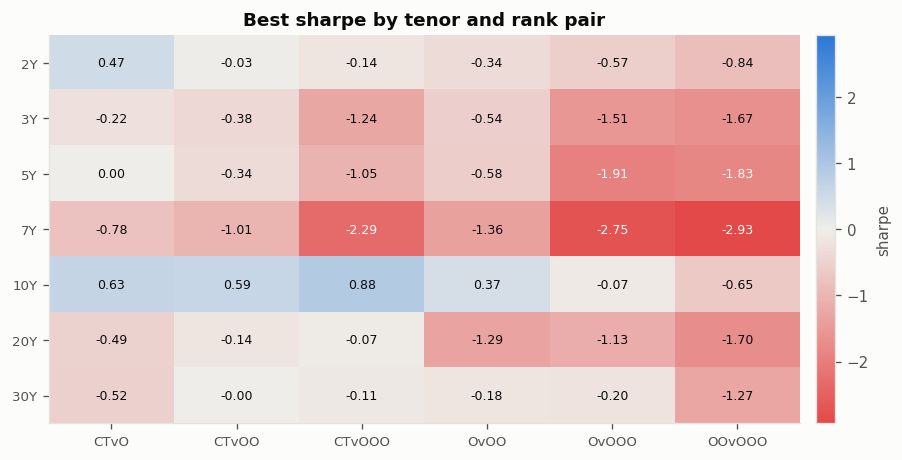

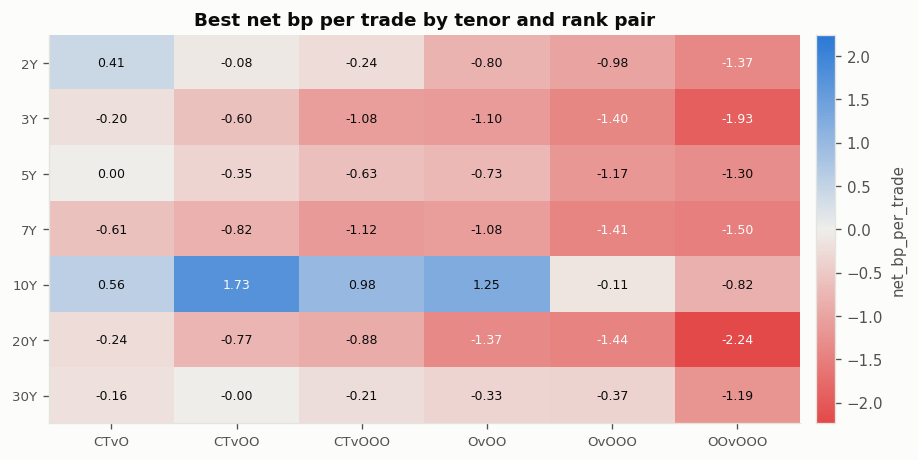

In [11]:
F.plot_league_heatmap(scored, value="sharpe")
plt.show()
F.plot_league_heatmap(scored, value="net_bp_per_trade",
                      title="Best net bp per trade by tenor and rank pair")
plt.show()

## 6. Placebo — the same rules, entered off the auction clock

The premium is created at an auction. Shift entry away from the roll and a real auction
mechanism must degrade. If the shifted book performs as well, whatever is being measured
is not the on-the-run premium and the auction story is decoration.

In [12]:
top = scored.head(12)["name"].tolist()
pl_cfgs = G.placebo_grid([c for c in cfgs if c.name in top], shifts=(7, 14, -7))
pl_league, pl_daily, _ = G.run_grid(p_fin, amap, pl_cfgs, progress=False)
print(f"top-12 mean Sharpe  : {scored[scored['name'].isin(top)]['sharpe'].mean():+.3f}")
print(f"placebo mean Sharpe : {pl_league['sharpe'].mean():+.3f}")
display(pl_league[["name", "n_trades", "net_bp_per_trade", "sharpe"]].round(4).head(12))

top-12 mean Sharpe  : +0.584
placebo mean Sharpe : -0.075


,name,n_trades,net_bp_per_trade,sharpe
0,2Y_CTvO_LONGCUR_e1_10d_z250@1.0_pl7_finmodelle...,33,-0.4741,-0.5773
1,2Y_CTvO_LONGCUR_e1_10d_z250@1.0_pl14_finmodell...,35,-0.4147,-0.5106
2,2Y_CTvO_LONGCUR_e1_10d_z250@1.0_pl-7_finmodell...,39,-0.3096,-0.3855
3,2Y_CTvO_LONGCUR_e3_10d_z250@1.0_pl7_finmodelle...,36,-0.1371,-0.1503
4,2Y_CTvO_LONGCUR_e3_10d_z250@1.0_pl14_finmodell...,45,-0.2774,-0.3387
5,2Y_CTvO_LONGCUR_e3_10d_z250@1.0_pl-7_finmodell...,43,-0.3329,-0.4118
6,10Y_CTvO_LONGOLD_e3_nr+1_z250@1.0_pl7_finmodel...,26,0.4254,0.4148
7,10Y_CTvO_LONGOLD_e3_nr+1_z250@1.0_pl14_finmode...,18,-0.0291,-0.0243
8,10Y_CTvO_LONGOLD_e3_nr+1_z250@1.0_pl-7_finmode...,4,0.5461,0.5345
9,10Y_CTvO_LONGOLD_e5_nr+1_z250@1.0_pl7_finmodel...,26,0.3839,0.3578


## 7. What the search cost — deflated Sharpe

Trials counted = grid + placebo. `apply_dsr_gate` would default to `len(results)`, which
is the wrong count when the frame in hand is one slice of a larger search.

In [13]:
n_trials = len(cfgs) + len(pl_cfgs)
defl = A.deflate_league(scored, {**daily, **pl_daily}, n_trials=n_trials)
defl["verdict"] = defl.apply(A.verdict_row, axis=1)
print(f"trials {n_trials}   sr_var {defl['sr_variance'].iloc[0]:.4f}   "
      f"E[max Sharpe | null] {defl['sr_star'].iloc[0]:.3f}")
display(defl.head(20)[["name", "tenor", "pair", "n_trades", "net_bp_per_trade",
                       "sharpe", "dsr_prob", "breakeven_cost_mult", "verdict"]].round(4))
print(defl["verdict"].value_counts().to_string())

trials 3396   sr_var 2.4279   E[max Sharpe | null] 5.591


,name,tenor,pair,n_trades,net_bp_per_trade,sharpe,dsr_prob,breakeven_cost_mult,verdict
0,10Y_CTvOOO_LONGOLD_e10_nr+1_z250@1.0_finmodell...,10,CTvOOO,26,0.9496,0.8761,0.0,1.9822,SELECTION-ARTIFACT
1,10Y_CTvOOO_LONGOLD_e5_nr+1_z250@1.0_finmodelle...,10,CTvOOO,28,0.9835,0.8326,0.0,2.0193,SELECTION-ARTIFACT
2,10Y_CTvOOO_LONGOLD_e3_nr+1_z250@1.0_finmodelle...,10,CTvOOO,29,0.8486,0.6924,0.0,1.8808,SELECTION-ARTIFACT
3,10Y_CTvO_LONGOLD_e10_nr+1_z250@1.0_finmodelled_c1,10,CTvO,26,0.5622,0.6268,0.0,1.8418,SELECTION-ARTIFACT
4,10Y_CTvOOO_LONGOLD_e1_nr+1_z250@1.0_finmodelle...,10,CTvOOO,24,0.7432,0.5918,0.0,1.7774,SELECTION-ARTIFACT
5,10Y_CTvOO_LONGOLD_e10_42d_z250@1.0_finmodelled_c1,10,CTvOO,24,1.7264,0.5884,0.0,2.9953,SELECTION-ARTIFACT
6,10Y_CTvO_LONGOLD_e5_nr+1_z250@1.0_finmodelled_c1,10,CTvO,27,0.4960,0.5065,0.0,1.7412,SELECTION-ARTIFACT
7,2Y_CTvO_LONGCUR_e1_10d_z250@1.0_finmodelled_c1,2,CTvO,31,0.3823,0.4746,0.0,1.3608,SELECTION-ARTIFACT
8,10Y_CTvOO_LONGOLD_e1_nr+1_z250@1.0_finmodelled_c1,10,CTvOO,24,0.5476,0.4692,0.0,1.6386,SELECTION-ARTIFACT
9,10Y_CTvO_LONGOLD_e3_nr+1_z250@1.0_finmodelled_c1,10,CTvO,27,0.4667,0.4583,0.0,1.6967,SELECTION-ARTIFACT


verdict
DEAD (negative net)      2974
SELECTION-ARTIFACT         66
DEAD (too few trades)      44


## 8. Cost curve and break-even

,cost_multiplier,n_trades,net_bp,net_bp_per_trade,sharpe,t_stat_nw,hit_rate
0,0.00,26,49.8249,1.9163,1.8294,4.6994,0.8077
1,0.25,26,43.5408,1.6746,1.5973,4.0886,0.7692
2,0.50,26,37.2568,1.4330,1.3584,3.4481,0.7692
3,0.75,26,30.9728,1.1913,1.1167,2.7992,0.6923
4,1.00,26,24.6888,0.9496,0.8761,2.1616,0.6154
5,1.50,26,12.1208,0.4662,0.4115,0.9782,0.5385
6,2.00,26,-0.4473,-0.0172,-0.0143,-0.0328,0.3462
7,3.00,26,-25.5834,-0.9840,-0.7157,-1.5317,0.2308


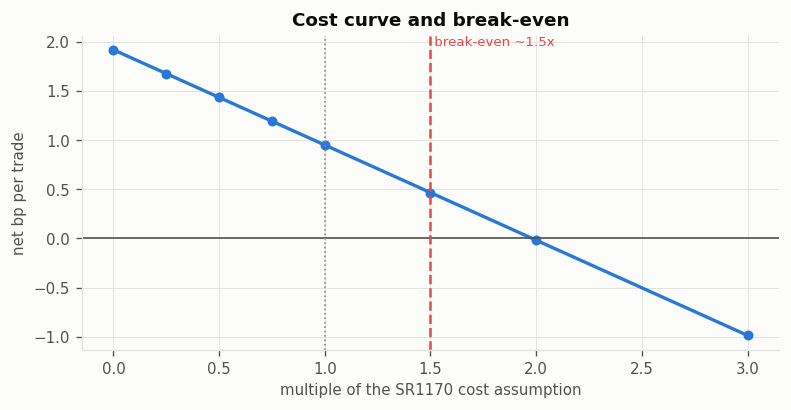

In [14]:
best_cfg = next(c for c in cfgs if c.name == defl.iloc[0]["name"])
cc = G.cost_curve(panel, amap, best_cfg)
display(cc.round(4))
F.plot_cost_curve(cc)
plt.show()

## 9. Seasonality

Two clocks, and they are not interchangeable. The **auction-cycle** clock is the
mechanism: the premium is created at one auction and released at the next, so a real
effect must concentrate somewhere on this axis. The **calendar** clock is the
conventional one. For 2y/3y/5y/7y (monthly auctions) the two nearly coincide; for
10y/20y/30y (quarterly) they separate cleanly, which is what makes the comparison
informative.

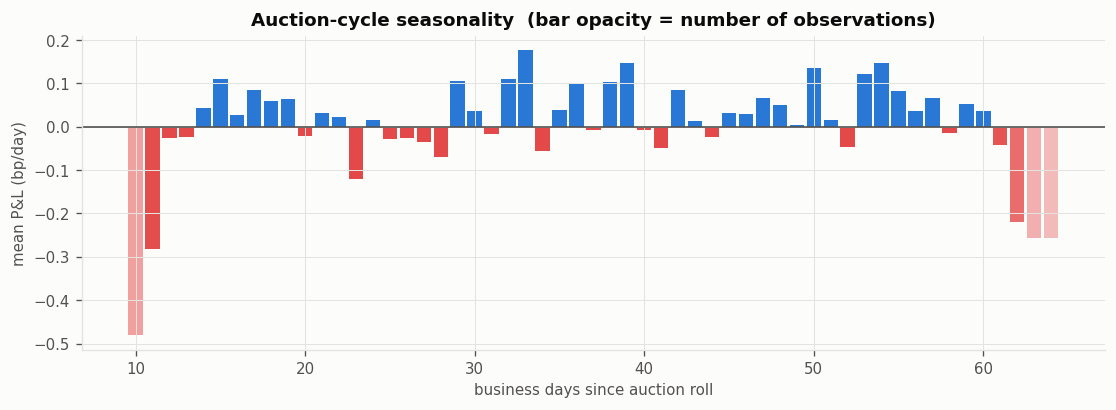

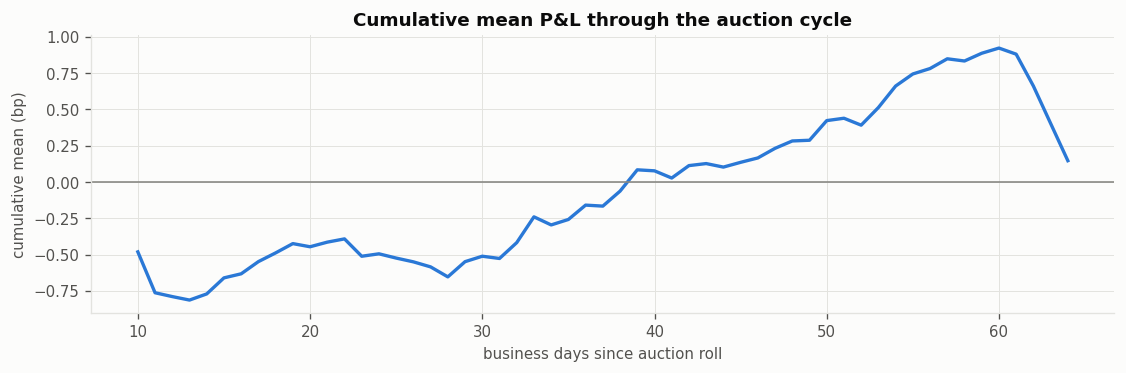

In [15]:
best_res = results[defl.iloc[0]["name"]]
cyc = A.auction_cycle_profile(best_res)
F.plot_auction_cycle(cyc)
plt.show()
F.plot_cycle_cumulative(cyc)
plt.show()

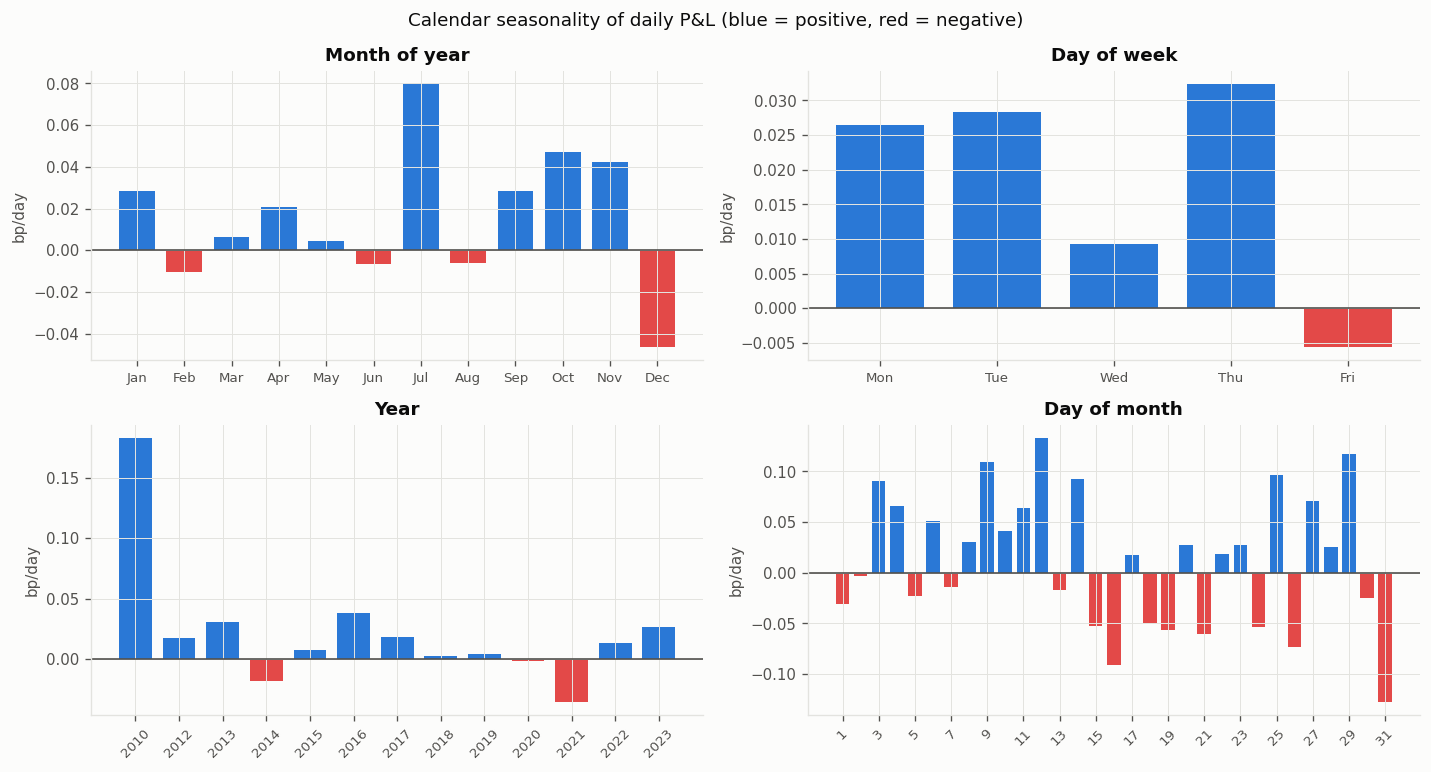

In [16]:
seas = A.calendar_seasonality(best_res)
F.plot_calendar_seasonality(seas)
plt.show()

### 9.1 Pooled across every long-old config

One configuration's calendar is noise. Pooling every long-old cell, weighted by
observation count, is the honest version of the same picture.

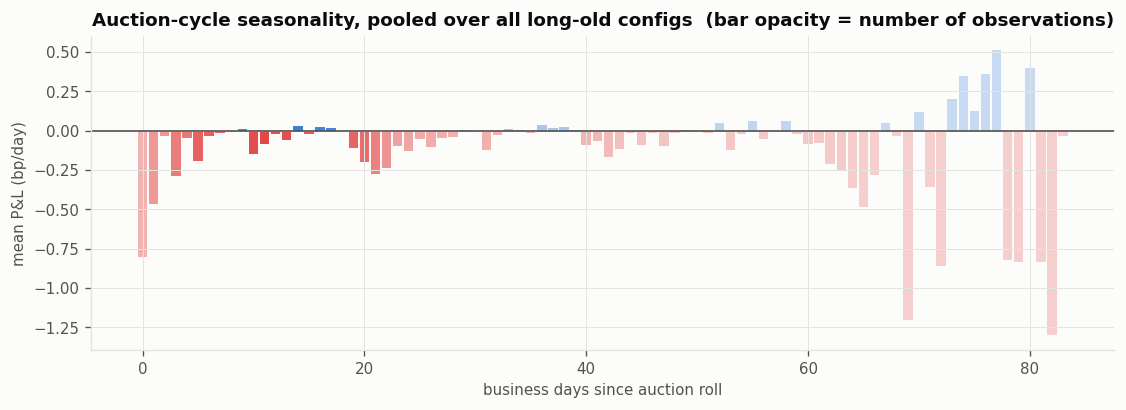

In [17]:
pool = []
for nm, r in results.items():
    if r.config.direction > 0 and not r.trades.empty:
        c = A.auction_cycle_profile(r)
        if not c.empty:
            c["tenor"] = r.config.tenor
            pool.append(c)
allc = pd.concat(pool, ignore_index=True)
g = (allc.groupby("cycle_day")
     .apply(lambda d: pd.Series({"n": d["n"].sum(),
                                 "mean_pnl_bp": np.average(d["mean_pnl_bp"], weights=d["n"]),
                                 "mean_price_bp": np.average(d["mean_price_bp"], weights=d["n"])}),
            include_groups=False)
     .reset_index())
F.plot_auction_cycle(g.assign(cum_mean_pnl_bp=g["mean_pnl_bp"].cumsum()),
                     title="Auction-cycle seasonality, pooled over all long-old configs")
plt.show()

## 10. Robustness

Financing modes side by side, and a per-year split. A strategy alive in one regime and
dead in three is not alive.

,n_trades,net_bp_per_trade,special_bp_per_trade,sharpe,t_stat_nw,hit_rate
none,26,1.382812,0.0,1.274937,3.164967,0.730769
modelled,26,0.949569,-0.590214,0.87608,2.161589,0.615385
actual,11,0.294244,-0.61813,0.277775,0.496985,0.636364


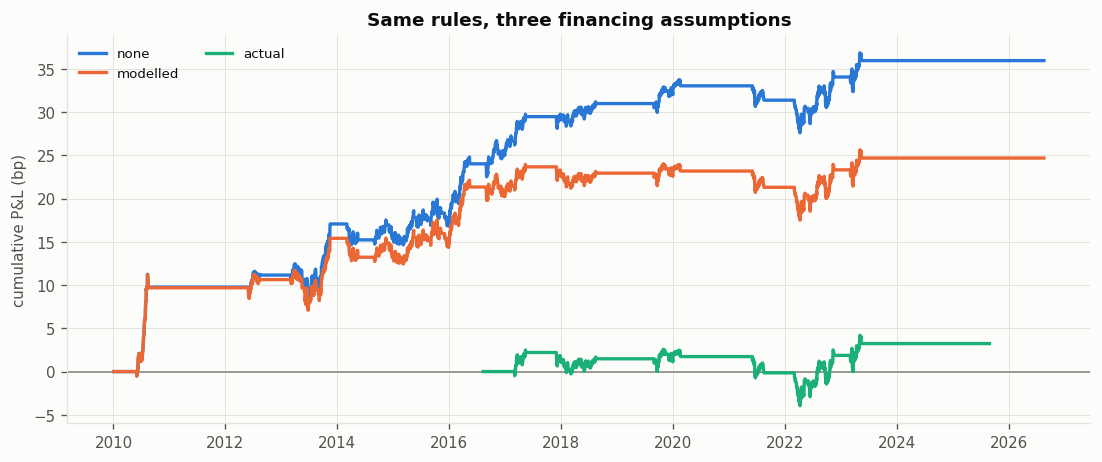

In [18]:
rows = {}
for mode in ("none", "modelled", "actual"):
    c = SwitchConfig(**{**best_cfg.__dict__, "financing_mode": mode})
    r = run_switch(select_financing(panel, mode), amap, c, cost_model=CostModel())
    rows[mode] = A.summarize_switch(r)
    if not r.daily.empty:
        rows[mode]["_eq"] = r.equity_bp
eq = {m: v.pop("_eq") for m, v in rows.items() if "_eq" in v}
display(pd.DataFrame(rows).T[["n_trades", "net_bp_per_trade", "special_bp_per_trade",
                              "sharpe", "t_stat_nw", "hit_rate"]].round(4))
F.plot_equity(eq, title="Same rules, three financing assumptions")
plt.show()

In [19]:
from RVUtils.BasisVsVol.analytics import regime_split
best_daily = results[defl.iloc[0]["name"]].daily.rename(columns={"pnl_bp": "pnl"})
display(regime_split(best_daily, col="pnl", by="year").round(4))

,period,n_days,total_volbp,sharpe
0,2010,251,9.6880,2.8535
1,2011,250,0.0000,NaN
2,2012,250,0.9478,0.5209
3,2013,250,4.7762,1.0162
4,2014,248,-2.2230,-0.6605
5,2015,251,1.5947,0.3565
6,2016,250,5.9369,1.4413
7,2017,250,1.8429,0.6217
8,2018,249,0.3815,0.1228
9,2019,250,0.2935,0.1153


## 11. Trade log

In [20]:
OUT = pathlib.Path(REPO) / "notebooks/backtests/ust_switch/_out"
OUT.mkdir(parents=True, exist_ok=True)
tl = results[defl.iloc[0]["name"]].trades.copy()
tl["cum_bp"] = tl["net_bp"].cumsum()
tl.to_csv(OUT / "best_trade_log.csv", index=False)
defl.to_csv(OUT / "league_deflated.csv", index=False)
display(tl.round(4).tail(20))

,cycle,roll,next_roll,entry,exit,held_days,held_obs,cusip_young,cusip_old,spread_entry_bp,spread_exit_bp,d_spread_bp,price_bp,carry_bp,special_bp,cost_bp,gross_bp,net_bp,mod_dur_young,mod_dur_old,financing_actual_frac,cum_bp
6,18,2014-08-18,2014-11-18,2014-09-02,2014-11-17,76,52,912828D56,912828WE6,-5.5248,-8.2487,-2.7239,2.7239,-0.0850,-0.4177,0.9865,2.6389,1.6524,8.8000,8.0526,0.0000,14.8720
7,19,2014-11-18,2015-02-18,2014-12-04,2015-02-17,75,49,912828G38,912828B66,-5.8210,-5.0836,0.7375,-0.7375,-0.1008,-0.4124,0.9837,-0.8383,-1.8219,8.8609,8.0662,0.0000,13.0501
8,20,2015-02-18,2015-05-18,2015-03-04,2015-05-15,72,53,912828J27,912828WJ5,-2.4381,-5.9777,-3.5396,3.5396,-0.0827,-0.4162,0.9733,3.4569,2.4836,8.9678,8.1485,0.0000,15.5337
9,21,2015-05-18,2015-08-18,2015-06-02,2015-08-17,76,54,912828XB1,912828D56,-2.3321,-3.0386,-0.7064,0.7064,-0.0192,-0.4132,0.9719,0.6872,-0.2847,8.9019,8.1823,0.0000,15.2489
10,22,2015-08-18,2015-11-17,2015-09-01,2015-11-16,76,52,912828K74,912828G38,-1.2700,-3.0111,-1.7411,1.7411,-0.0618,-0.4204,0.9665,1.6793,0.7128,8.9640,8.2251,0.0000,15.9617
11,23,2015-11-17,2016-02-17,2015-12-02,2016-02-16,76,51,912828M56,912828J27,-0.2964,-2.8357,-2.5393,2.5393,-0.1663,-0.4255,0.9617,2.3729,1.4112,8.8709,8.3060,0.0000,17.3729
12,24,2016-02-17,2016-05-17,2016-03-02,2016-05-16,75,53,912828P46,912828XB1,0.7946,-4.2809,-5.0755,5.0755,-0.1518,-0.4221,0.9563,4.9237,3.9674,9.1329,8.2918,0.0000,21.3403
13,26,2016-08-16,2016-11-16,2016-08-30,2016-11-15,77,53,9128282A7,912828M56,-0.5551,-2.6559,-2.1008,2.1008,-1.2641,-1.5387,0.9555,0.8367,-0.1188,9.2048,8.2810,1.0000,21.2215
14,27,2016-11-16,2017-02-16,2016-12-01,2017-02-15,76,52,912828U24,912828P46,0.7939,-1.6663,-2.4603,2.4603,-1.2658,-1.5184,0.9510,1.1944,0.2435,8.9343,8.4112,1.0000,21.4650
15,28,2017-02-16,2017-05-16,2017-03-03,2017-05-15,73,51,912828V98,912828R36,1.2185,-2.5394,-3.7578,3.7578,-0.5955,-0.7524,0.9548,3.1624,2.2076,8.8348,8.3971,1.0000,23.6725


## 12. Reading this notebook

**Kill conditions, in the order they should be checked.**

1. §2.1 — if the yield pickup is not monotone in rank for a tenor, that tenor's cells are
   measuring curve slope, not liquidity, whatever their Sharpe says.
2. §3 — if the reconciliation does not both PASS as configured and FAIL under the two
   mutations, nothing below it means anything.
3. §6 — if the placebo Sharpe is not materially below the real one, the auction
   mechanism is not what is being harvested.
4. §7 — a row with `dsr_prob < 0.95` is SELECTION-ARTIFACT, not a strategy.
5. §8 — `breakeven_cost_mult` below ~1.5 means the result lives inside the error bar of
   the cost assumption, and SR1170's spreads are measured off *executed* trades, so they
   are if anything optimistic for the deep-old legs.

**What would change the answer.** Per-issue financing beyond the JPM window (2016-08 to
2025-08) is modelled; a real repo history for 2010–2016 would firm up 40% of the sample.
A Citi Velocity cross-check is written and ready in `tie_out_citi_repo.py` but was
blocked on the Excel add-in transport.